# Tabu Search — TSP Benchmark

Standard TSP (no time windows, no perturbations).  
Compares **Tabu Search** against classical baselines.

| Section | Content |
|---------|----------|
| 1 | Imports & solver setup |
| 2 | Baseline helpers (NN, 2-opt, brute-force optimal) |
| 3 | Benchmark n=10 — comparison with brute-force optimal |
| 4 | Benchmark n=50, n=100 |
| 5 | Summary table + bar chart |
| 6 | Tour visualisation |
| 7 | demo_overview.png generation (4-panel) |

## Section 1 — Imports & solver setup

In [1]:
import sys, os, time
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import permutations

# Add solver directory to path
SOLVER_DIR = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, SOLVER_DIR)

from solver import TabuSearch
from data   import random_instance, tour_length, load_cities, optimal_tour

torch.manual_seed(42)

# ── Tabu Search configuration (medium) ─────────────────────────────────────
TS_CONFIG = dict(
    tabu_tenure = 20,
    max_iter    = 5000,
    patience    = 500,
    seed        = 42,
)

print("Tabu Search TSP Benchmark")
print(f"Config: {TS_CONFIG}")

Tabu Search TSP Benchmark
Config: {'tabu_tenure': 20, 'max_iter': 5000, 'patience': 500, 'seed': 42}


## Section 2 — Baseline helpers

In [2]:
def run_nn(coords: torch.Tensor):
    """Nearest-neighbour tour starting from city 0."""
    n = coords.shape[0]
    dist = torch.cdist(coords, coords)
    visited = torch.zeros(n, dtype=torch.bool)
    tour = [0]; visited[0] = True
    for _ in range(n - 1):
        d = dist[tour[-1]].clone()
        d[visited] = float('inf')
        nxt = d.argmin().item()
        tour.append(nxt); visited[nxt] = True
    return tour


def run_2opt(coords: torch.Tensor, tour=None):
    """2-opt improvement on a given (or NN) tour."""
    if tour is None:
        tour = run_nn(coords)
    n = len(tour)
    dist = torch.cdist(coords, coords)
    improved = True
    while improved:
        improved = False
        for i in range(n - 1):
            for j in range(i + 2, n):
                if i == 0 and j == n - 1:
                    continue
                a, b = tour[i], tour[(i + 1) % n]
                c, d = tour[j], tour[(j + 1) % n]
                delta = (dist[a, c] + dist[b, d] - dist[a, b] - dist[c, d]).item()
                if delta < -1e-10:
                    tour[i+1:j+1] = tour[i+1:j+1][::-1]
                    improved = True
    return tour


def run_ts(coords: torch.Tensor):
    """Run Tabu Search with medium config."""
    ts = TabuSearch(coords, **TS_CONFIG)
    best_tour, best_len, history = ts.run()
    return best_tour, best_len, history


def gap(val, ref):
    """Gap (%) relative to reference; negative = better than ref."""
    if ref < 1e-9:
        return float('nan')
    return (val - ref) / ref * 100.0


print("Helpers defined.")

Helpers defined.


## Section 3 — Benchmark n=10 (with brute-force optimal)

For n=10, brute-force optimal is feasible (9! = 362 880 permutations).

In [3]:
N_TRIALS_10 = 50
res10 = {'nn': [], '2opt': [], 'ts': [], 'optimal': []}
times10 = {'nn': [], '2opt': [], 'ts': []}
histories10 = []

for seed in range(N_TRIALS_10):
    coords = random_instance(10, seed=seed)

    # Optimal
    opt_tour, opt_len = optimal_tour(coords)
    res10['optimal'].append(opt_len)

    # NN
    t0 = time.perf_counter()
    nn = run_nn(coords)
    times10['nn'].append(time.perf_counter() - t0)
    res10['nn'].append(tour_length(coords, nn))

    # 2-opt
    t0 = time.perf_counter()
    t2 = run_2opt(coords, list(nn))
    times10['2opt'].append(time.perf_counter() - t0)
    res10['2opt'].append(tour_length(coords, t2))

    # Tabu Search
    t0 = time.perf_counter()
    ts_tour, ts_len, hist = run_ts(coords)
    times10['ts'].append(time.perf_counter() - t0)
    res10['ts'].append(ts_len)
    if seed < 5:
        histories10.append(hist)

print(f"n=10 over {N_TRIALS_10} trials:")
print(f"  NN       avg={np.mean(res10['nn']):.4f}  time={np.mean(times10['nn'])*1000:.2f}ms")
print(f"  2-opt    avg={np.mean(res10['2opt']):.4f}  gap vs NN={gap(np.mean(res10['2opt']), np.mean(res10['nn'])):.1f}%")
print(f"  TS       avg={np.mean(res10['ts']):.4f}  gap vs NN={gap(np.mean(res10['ts']), np.mean(res10['nn'])):.1f}%  time={np.mean(times10['ts'])*1000:.1f}ms")
print(f"  Optimal  avg={np.mean(res10['optimal']):.4f}  gap vs NN={gap(np.mean(res10['optimal']), np.mean(res10['nn'])):.1f}%")

n=10 over 50 trials:
  NN       avg=3.0469  time=0.11ms
  2-opt    avg=2.7789  gap vs NN=-8.8%
  TS       avg=2.7703  gap vs NN=-9.1%  time=71.0ms
  Optimal  avg=2.7703  gap vs NN=-9.1%


## Section 4 — Benchmark n=50, n=100

No brute-force optimal at this scale — gap reported relative to NN baseline.

In [4]:
N_TRIALS_LARGE = 20
all_results = {}   # {n: {method: [lengths]}}
all_times   = {}   # {n: {method: [seconds]}}
all_histories = {} # {n: [history_list]} — store first 3 per size

for N in [50, 100]:
    res = {'nn': [], '2opt': [], 'ts': []}
    tms = {'nn': [], '2opt': [], 'ts': []}
    hists = []

    for seed in range(N_TRIALS_LARGE):
        coords = random_instance(N, seed=seed)

        t0 = time.perf_counter()
        nn = run_nn(coords)
        tms['nn'].append(time.perf_counter() - t0)
        res['nn'].append(tour_length(coords, nn))

        t0 = time.perf_counter()
        t2 = run_2opt(coords, list(nn))
        tms['2opt'].append(time.perf_counter() - t0)
        res['2opt'].append(tour_length(coords, t2))

        t0 = time.perf_counter()
        ts_tour, ts_len, hist = run_ts(coords)
        tms['ts'].append(time.perf_counter() - t0)
        res['ts'].append(ts_len)
        if len(hists) < 3:
            hists.append(hist)

    all_results[N]   = res
    all_times[N]     = tms
    all_histories[N] = hists

    nn_avg = np.mean(res['nn'])
    print(f"n={N} over {N_TRIALS_LARGE} trials:")
    print(f"  NN    avg={nn_avg:.4f}")
    print(f"  2-opt avg={np.mean(res['2opt']):.4f}  gap={gap(np.mean(res['2opt']), nn_avg):.1f}%")
    print(f"  TS    avg={np.mean(res['ts']):.4f}  gap={gap(np.mean(res['ts']), nn_avg):.1f}%  time={np.mean(tms['ts']):.3f}s")
    print()

n=50 over 20 trials:
  NN    avg=7.1567
  2-opt avg=6.0832  gap=-15.0%
  TS    avg=5.8282  gap=-18.6%  time=5.791s

n=100 over 20 trials:
  NN    avg=9.8126
  2-opt avg=8.3997  gap=-14.4%
  TS    avg=8.0161  gap=-18.3%  time=30.618s



## Section 5 — Summary table + bar chart

    n Method             Avg length  Gap vs NN (%)   Avg time (s)
-----------------------------------------------------------------
   10 NN                     3.0469           0.0%         0.1 ms
   10 2-opt                  2.7789          -8.8%         0.4 ms
   10 Tabu Search            2.7703          -9.1%        71.0 ms
   10 Optimal                2.7703          -9.1%              —

   50 NN                     7.1567           0.0%        0.0004 s
   50 2-opt                  6.0832         -15.0%        0.0245 s
   50 Tabu Search            5.8282         -18.6%        5.7912 s

  100 NN                     9.8126           0.0%        0.0006 s
  100 2-opt                  8.3997         -14.4%        0.1225 s
  100 Tabu Search            8.0161         -18.3%       30.6179 s



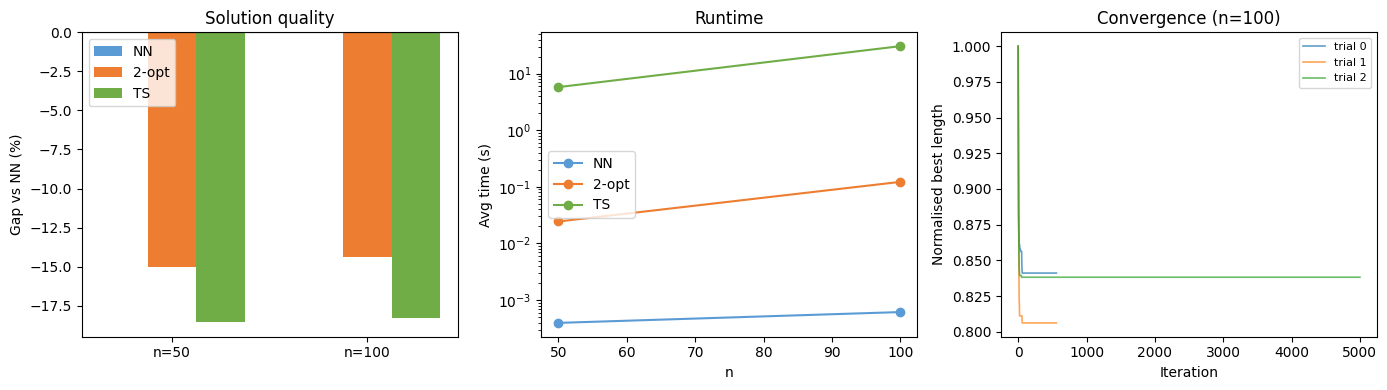

Saved figures/benchmark_summary.png


In [5]:
# ── Summary table ───────────────────────────────────────────────────────────
print(f"{'n':>5} {'Method':<16} {'Avg length':>12} {'Gap vs NN (%)':>14} {'Avg time (s)':>14}")
print('-' * 65)

# n=10
nn10 = np.mean(res10['nn'])
for method, label in [('nn','NN'), ('2opt','2-opt'), ('ts','Tabu Search'), ('optimal','Optimal')]:
    avg = np.mean(res10[method])
    g   = gap(avg, nn10) if method != 'nn' else 0.0
    t   = np.mean(times10[method])*1000 if method in times10 else float('nan')
    t_str = f"{t:.1f} ms" if not np.isnan(t) else "—"
    print(f"{'10':>5} {label:<16} {avg:>12.4f} {g:>13.1f}%  {t_str:>13}")

print()
for N in [50, 100]:
    res = all_results[N]; tms = all_times[N]
    nn_avg = np.mean(res['nn'])
    for method, label in [('nn','NN'), ('2opt','2-opt'), ('ts','Tabu Search')]:
        avg = np.mean(res[method])
        g   = gap(avg, nn_avg) if method != 'nn' else 0.0
        t   = np.mean(tms[method])
        print(f"{N:>5} {label:<16} {avg:>12.4f} {g:>13.1f}%  {t:>12.4f} s")
    print()

# ── Bar chart ───────────────────────────────────────────────────────────────
COLORS = {'nn': '#5B9BD5', '2opt': '#ED7D31', 'ts': '#70AD47'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Gap vs NN for n=50 and n=100
ax = axes[0]
sizes = [50, 100]
x = np.arange(len(sizes))
w = 0.25
for k, (method, label) in enumerate([('nn','NN'), ('2opt','2-opt'), ('ts','TS')]):
    gaps = []
    for N in sizes:
        res = all_results[N]
        nn_avg = np.mean(res['nn'])
        gaps.append(gap(np.mean(res[method]), nn_avg))
    ax.bar(x + k * w, gaps, w, label=label, color=COLORS[method])
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x + w); ax.set_xticklabels([f'n={n}' for n in sizes])
ax.set_ylabel('Gap vs NN (%)')
ax.set_title('Solution quality')
ax.legend()

# Panel 2: Runtime
ax = axes[1]
for method, label in [('nn','NN'), ('2opt','2-opt'), ('ts','TS')]:
    rts = [np.mean(all_times[N][method]) for N in sizes]
    ax.plot(sizes, rts, 'o-', label=label, color=COLORS[method])
ax.set_xlabel('n'); ax.set_ylabel('Avg time (s)')
ax.set_title('Runtime')
ax.set_yscale('log')
ax.legend()

# Panel 3: Convergence curves for n=100
ax = axes[2]
hists = all_histories[100]
for i, hist in enumerate(hists):
    norm = hist[0] if hist[0] > 1e-9 else 1.0
    ax.plot([h / norm for h in hist], alpha=0.7, linewidth=1.2,
            label=f'trial {i}' if i < 3 else None)
ax.set_xlabel('Iteration'); ax.set_ylabel('Normalised best length')
ax.set_title('Convergence (n=100)')
ax.legend(fontsize=8)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/benchmark_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figures/benchmark_summary.png")

## Section 6 — Tour visualisation

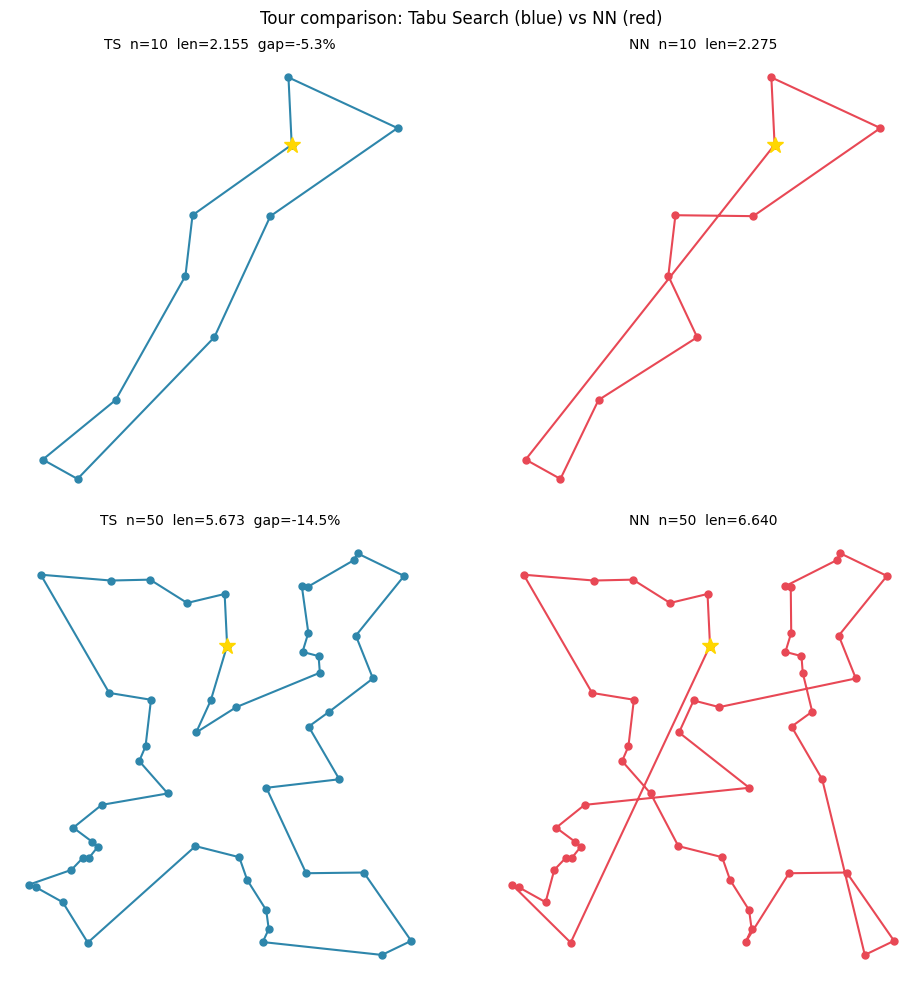

Saved figures/benchmark_tours.png


In [6]:
def draw_tour(ax, coords, tour, color, title, alpha=1.0):
    xy = coords.numpy()
    closed = tour + [tour[0]]
    xs = xy[closed, 0]; ys = xy[closed, 1]
    ax.plot(xs, ys, '-o', color=color, markersize=5, alpha=alpha, linewidth=1.5)
    ax.plot(xy[tour[0], 0], xy[tour[0], 1], '*', color='gold',
            markersize=12, zorder=5, label='Start')
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal'); ax.axis('off')


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for row, N in enumerate([10, 50]):
    coords = random_instance(N, seed=0)
    nn_tour = run_nn(coords)
    ts_tour, ts_len, _ = run_ts(coords)

    nn_len = tour_length(coords, nn_tour)
    g = gap(ts_len, nn_len)

    draw_tour(axes[row, 0], coords, ts_tour, '#2E86AB',
              f'TS  n={N}  len={ts_len:.3f}  gap={g:.1f}%')
    draw_tour(axes[row, 1], coords, nn_tour, '#E84855',
              f'NN  n={N}  len={nn_len:.3f}')

plt.suptitle('Tour comparison: Tabu Search (blue) vs NN (red)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/benchmark_tours.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figures/benchmark_tours.png")

## Section 7 — demo_overview.png (4-panel)

Four panels on a seed-0, n=10 instance:
1. **Convergence curve** — TS best-tour length per iteration
2. **Method comparison** bar chart (NN / 2-opt / TS / Optimal)
3. **Optimal tour** (green)
4. **TS tour** (blue) with gap to optimal

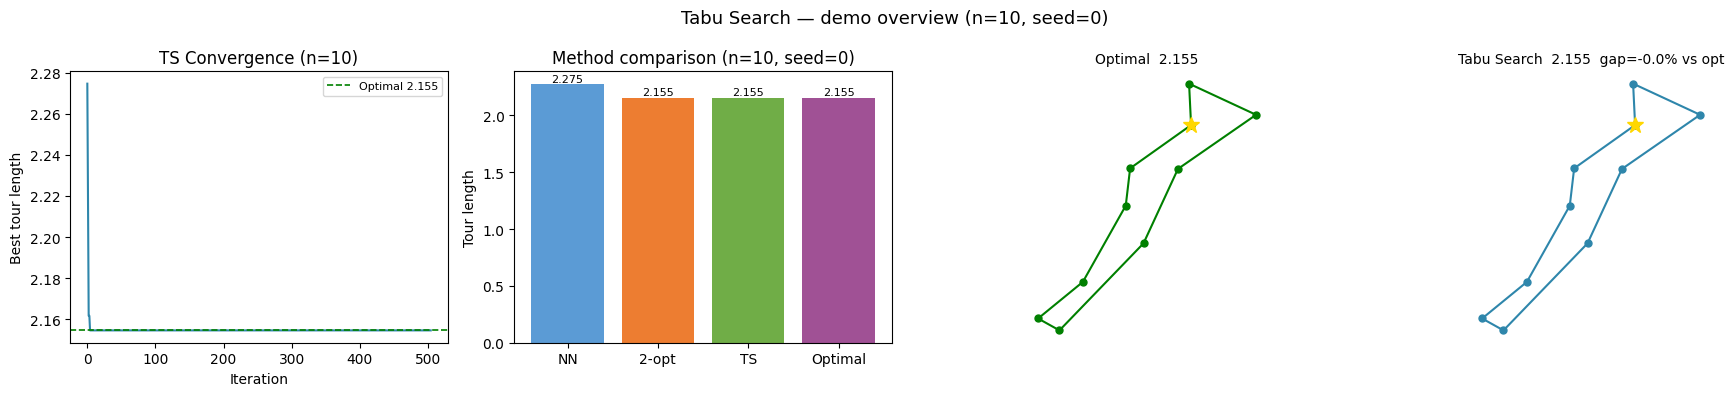

Saved figures/demo_overview.png


In [7]:
DEMO_N    = 10
DEMO_SEED = 0

coords_demo = random_instance(DEMO_N, seed=DEMO_SEED)
opt_tour_demo, opt_len_demo = optimal_tour(coords_demo)
nn_tour_demo  = run_nn(coords_demo)
nn_len_demo   = tour_length(coords_demo, nn_tour_demo)
t2_tour_demo  = run_2opt(coords_demo, list(nn_tour_demo))
t2_len_demo   = tour_length(coords_demo, t2_tour_demo)
ts_tour_demo, ts_len_demo, hist_demo = run_ts(coords_demo)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Panel 1: convergence curve
ax = axes[0]
ax.plot(hist_demo, color='#2E86AB', linewidth=1.5)
ax.axhline(opt_len_demo, color='green', linestyle='--', linewidth=1.2, label=f'Optimal {opt_len_demo:.3f}')
ax.set_xlabel('Iteration'); ax.set_ylabel('Best tour length')
ax.set_title('TS Convergence (n=10)')
ax.legend(fontsize=8)

# Panel 2: method comparison bar chart
ax = axes[1]
methods = ['NN', '2-opt', 'TS', 'Optimal']
vals    = [nn_len_demo, t2_len_demo, ts_len_demo, opt_len_demo]
colors  = ['#5B9BD5', '#ED7D31', '#70AD47', '#A05195']
bars = ax.bar(methods, vals, color=colors)
ax.set_ylabel('Tour length')
ax.set_title('Method comparison (n=10, seed=0)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Panel 3: optimal tour
ax = axes[2]
draw_tour(ax, coords_demo, opt_tour_demo, 'green',
          f'Optimal  {opt_len_demo:.3f}')

# Panel 4: TS tour
ax = axes[3]
g_opt = gap(ts_len_demo, opt_len_demo)
draw_tour(ax, coords_demo, ts_tour_demo, '#2E86AB',
          f'Tabu Search  {ts_len_demo:.3f}  gap={g_opt:.1f}% vs opt')

plt.suptitle(f'Tabu Search — demo overview (n={DEMO_N}, seed={DEMO_SEED})', fontsize=13)
plt.tight_layout()
plt.savefig('figures/demo_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figures/demo_overview.png")